# Introduction to Scikit-Learn (sklearn)


In [1]:
# Let's listify the contents
what_were_covering = [
    "0. An end-to-end Scikit-Learn workflow",
    "1. Getting the data ready",
    "2. Choose the right estimator/algorithm for our problems",
    "3. Fit the model/algorithm and use it to make predictions on our data",
    "4. Evaluating a model",
    "5. Improve a model",
    "6. Save and load a trained model",
    "7. Putting it all together!"]

## 0. An end to end Scikit-Learn Workflow

In [2]:
import numpy as np

In [3]:
import pandas as pd

In [4]:
import matplotlib.pyplot as plt

In [5]:
%matplotlib inline

In [6]:
import sklearn
print(sklearn.__version__)

1.9.0


In [7]:
heart_disease=pd.read_csv("heart-disease.csv")

In [8]:
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [9]:
#create X (features matrix)

In [10]:
X=heart_disease.drop("target", axis=1)

In [11]:
#create y(labels)
Y=heart_disease["target"]

In [12]:
# 2. Choose the right model and hyperparameters
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100)

# We'll keep the default hyperparameters
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [13]:
#3 Fit the model to the training data
from sklearn.model_selection import train_test_split #to slipt the data set into traning and testing data
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.5) #20% data will be used of testing rest fro training

In [14]:
clf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
Y_preds=clf.predict(X_test)

In [16]:
Y_preds

array([0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0])

In [17]:
Y_test

252    0
75     1
244    0
45     1
9      1
      ..
83     1
23     1
127    1
21     1
232    0
Name: target, Length: 152, dtype: int64

In [18]:
# 4. Evaluate the model on the training data and test data
clf.score(X_train, Y_train)

1.0

In [19]:
clf.score(X_test, Y_test)

0.7368421052631579

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(Y_test, Y_preds))

              precision    recall  f1-score   support

           0       0.73      0.64      0.68        67
           1       0.74      0.81      0.78        85

    accuracy                           0.74       152
   macro avg       0.74      0.73      0.73       152
weighted avg       0.74      0.74      0.73       152



In [21]:
confusion_matrix(Y_test, Y_preds)

array([[43, 24],
       [16, 69]])

In [22]:
accuracy_score(Y_test, Y_preds)

0.7368421052631579

In [23]:
# 5. Improve a model
# Try different amount of n_estimators
np.random.seed(42)
for i in range(10, 100, 10):
    print(f"Trying model with {i} estimators...")
    clf = RandomForestClassifier(n_estimators=i).fit(X_train, Y_train)
    print(f"Model accuracy on test set: {clf.score(X_test, Y_test) * 100:.2f}%")
    print("")

Trying model with 10 estimators...
Model accuracy on test set: 80.26%

Trying model with 20 estimators...
Model accuracy on test set: 76.97%

Trying model with 30 estimators...
Model accuracy on test set: 78.95%

Trying model with 40 estimators...
Model accuracy on test set: 77.63%

Trying model with 50 estimators...
Model accuracy on test set: 78.95%

Trying model with 60 estimators...
Model accuracy on test set: 76.97%

Trying model with 70 estimators...
Model accuracy on test set: 78.95%

Trying model with 80 estimators...
Model accuracy on test set: 78.95%

Trying model with 90 estimators...
Model accuracy on test set: 79.61%



In [24]:
import pickle

In [25]:
#saving a model 
pickle.dump(clf, open("random_forest_model001.pkl", "wb")) #wb is binary model001.pkl is model name

In [26]:
loaded_model=pickle.load(open("random_forest_model001.pkl", "rb"))
loaded_model.score(X_test, Y_test)

0.7960526315789473

# Employee Resgination Model

In [27]:
emp=pd.read_csv("employee_attrition_synthetic.csv")

In [28]:
emp

,employee_id,age,department,job_level,years_at_company,monthly_income_inr,overtime,job_satisfaction,work_life_balance,commute_km,training_hours_year,performance_rating,remote_days_per_week,left_company
0,1,28,Engineering,3,7,63800,0,5,1,38,54,2,0,0
1,2,22,HR,1,4,43200,0,4,5,18,0,4,1,0
2,3,48,Marketing,1,6,39500,0,4,1,23,44,4,0,0
3,4,45,Engineering,2,20,71700,0,1,1,43,29,4,0,0
4,5,35,Engineering,2,14,59900,1,3,2,43,34,4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,356,39,Operations,4,18,94400,1,2,5,13,58,5,4,0
356,357,21,Marketing,1,3,35700,0,5,3,22,14,4,2,0
357,358,57,Marketing,3,12,80600,1,4,4,38,3,3,2,0
358,359,25,Finance,3,7,65400,1,3,5,35,1,4,2,0


In [29]:
X=emp.drop(["employee_id", "department", "left_company"], axis=1) #removed columns which directly can't be used with RandomForest like string datatypes
#or columns like employee_id which has no effect on the final result - this is called feature selection

In [30]:
X

,age,job_level,years_at_company,monthly_income_inr,overtime,job_satisfaction,work_life_balance,commute_km,training_hours_year,performance_rating,remote_days_per_week
0,28,3,7,63800,0,5,1,38,54,2,0
1,22,1,4,43200,0,4,5,18,0,4,1
2,48,1,6,39500,0,4,1,23,44,4,0
3,45,2,20,71700,0,1,1,43,29,4,0
4,35,2,14,59900,1,3,2,43,34,4,5
...,...,...,...,...,...,...,...,...,...,...,...
355,39,4,18,94400,1,2,5,13,58,5,4
356,21,1,3,35700,0,5,3,22,14,4,2
357,57,3,12,80600,1,4,4,38,3,3,2
358,25,3,7,65400,1,3,5,35,1,4,2


In [31]:
#create y(labels)
y=emp["left_company"]

In [32]:
y

0      0
1      0
2      0
3      0
4      0
      ..
355    0
356    0
357    0
358    0
359    0
Name: left_company, Length: 360, dtype: int64

In [33]:
# 2. Choose the right model and hyperparameters
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# We'll keep the default hyperparameters
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [34]:
#3 Fit the model to the training data
from sklearn.model_selection import train_test_split #to slipt the data set into traning and testing data
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.6) #60% data will be used of testing rest fro training

In [35]:
print(X.shape)
print(y.shape)

(360, 11)
(360,)


In [36]:
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
y_preds=clf.predict(X_test)

In [38]:
y_preds

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [39]:
y_test

109    0
274    0
199    0
147    0
97     1
      ..
203    0
196    0
347    0
93     0
266    0
Name: left_company, Length: 216, dtype: int64

In [40]:
# 4. Evaluate the model on the training data and test data
clf.score(X_train, y_train)

1.0

In [41]:
clf.score(X_test, y_test)

0.8333333333333334

In [42]:
# Baseline :
#-n_estimators = 100
#-train = 100%
#-test  = 83.33%

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90       167
           1       0.78      0.37      0.50        49

    accuracy                           0.83       216
   macro avg       0.81      0.67      0.70       216
weighted avg       0.83      0.83      0.81       216



# Understanding n_estimators -> model accuracy relation

In [44]:
#1 creating spaces to store the results
n_estimators_values=[]
training_scores=[]
testing_scores=[]

KEEP CONSTANT
─────────────
X_train | 
y_train | 
X_test | 
y_test | 
random_state | 
other hyperparameters | 

CHANGE
──────
n_estimators

MEASURE
───────
training accuracy | 
testing accuracy | 

In [45]:
for i in range(10, 201, 10):
    clf=RandomForestClassifier(n_estimators=i, random_state=42)
    clf.fit(X_train, y_train)
    
    train_score=clf.score(X_train, y_train)
    test_score=clf.score(X_test, y_test)

    n_estimators_values.append(i)
    training_scores.append(train_score)
    testing_scores.append(test_score)

In [46]:
n_estimators_values

[10,
 20,
 30,
 40,
 50,
 60,
 70,
 80,
 90,
 100,
 110,
 120,
 130,
 140,
 150,
 160,
 170,
 180,
 190,
 200]

In [47]:
testing_scores

[0.8009259259259259,
 0.8009259259259259,
 0.8287037037037037,
 0.8379629629629629,
 0.8472222222222222,
 0.8472222222222222,
 0.8379629629629629,
 0.8333333333333334,
 0.8472222222222222,
 0.8472222222222222,
 0.8472222222222222,
 0.8564814814814815,
 0.8518518518518519,
 0.8472222222222222,
 0.8518518518518519,
 0.8518518518518519,
 0.8425925925925926,
 0.8472222222222222,
 0.8472222222222222,
 0.8518518518518519]

In [48]:
training_scores

[0.9930555555555556,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

In [49]:
import matplotlib.pyplot as plt

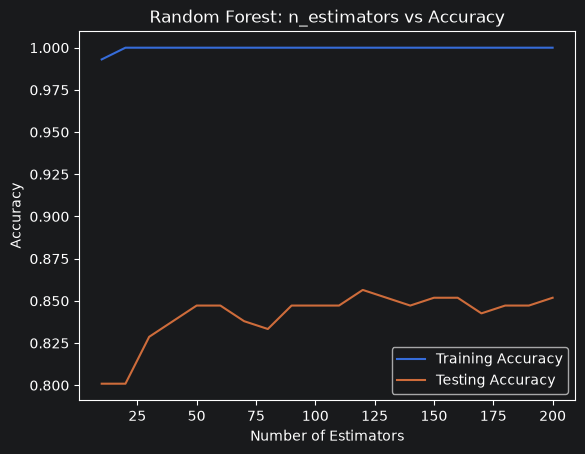

In [50]:
plt.plot(n_estimators_values, training_scores, label="Training Accuracy")
plt.plot(n_estimators_values, testing_scores, label="Testing Accuracy")

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Random Forest: n_estimators vs Accuracy")

plt.legend()
plt.show()

More trees ≠ automatically better prediction

The persistent gap:

Training ≈ 100%
Testing  ≈ 84–86%

is much more interesting than whether 120 trees beats 100 trees by 1%.

That suggests the model fits the training data extremely well but doesn't generalize equally well to unseen employees.

That's classic overfitting territory.

In [51]:
classification_report(y_test, y_preds)
confusion_matrix(y_test, y_preds)

array([[162,   5],
       [ 31,  18]])

model is excellent at predicting employees who stay, but pretty poor at catching employees who actually leave.
For employees who stayed:

162 correctly predicted stay
5 incorrectly predicted leave

But employees who actually resigned:

49 actually left////////
18 correctly detected
31 MISSED 

So the recall for the class we're probably most interested in is only:

18/31+18 ≈ 36.7%

Meaning HR department asks: "Which employees are at risk of resigning?"
and the model proceeds to miss roughly 63% of the actual resignations.

That's why the ~83% overall accuracy is deceptive.

In [52]:
print(classification_report(y_test, y_preds))
print(confusion_matrix(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90       167
           1       0.78      0.37      0.50        49

    accuracy                           0.83       216
   macro avg       0.81      0.67      0.70       216
weighted avg       0.83      0.83      0.81       216

[[162   5]
 [ 31  18]]


The model's 83% accuracy is flattering it. The class-1 metrics expose the problem
For 1 = left company:

Precision = 0.78
Recall    = 0.37
F1        = 0.50

The particularly ugly number is actually recall = 37%.

F1 = 0.50 summarizes the poor balance between that decent precision (0.78) and terrible recall (0.37).
The 0.78 precision tells something different. When the model does raise the alarm and say "this employee will leave", it's correct 78% of the time:

This is also why accuracy alone can be dangerous with imbalanced classes.

167 stay
 49 leave

So simply predicting 0 all the time would already achieve:

167 / 216≈  77.3%
the model has learned that predicting "stay" is usually the safer bet.

A completely useless "everyone stays" model gets 77% accuracy! Your Random Forest gets 83%, only about 6 percentage points higher.
That's a major lesson from this experiment.
For an HR attrition system, We should care much more about improving **class-1 recall** and F1 than squeezing accuracy from 83% to 85%.


In [53]:
#saving a model 
pickle.dump(clf, open("random_forest_employeeModel002.pkl", "wb")) #wb is binary model001.pkl is model name

# Using OneHotEncoder for feature scaling -> raw data to numbers